# GKX (2020) Replicatie — OLS & Elastic Net
## Financial Machine Learning Seminar

**Aanpassingen die ik heb verwerkt ten opzichte van de originele notebook:**
1. Recursief refit-schema: *expanding* training window + *rolling* 12-jaars validation window (zoals GKX §2.1, Internet App. D).
2. Hyperparameters worden **elk jaar opnieuw** getuned op de meegerolde validatie set (niet één keer in 1975–86 bevroren).
3. ENet grid verdicht: `alpha = logspace(-4, -1, 10)`, `l1_ratio = {0.5}`.
4. Validatiecriterium = **MSE** (zelfde loss als in training), niet R²oos.
5. Ik heb OLS-Full ook in de recursive loop opgenomen.
6. Huber ξ ook jaarlijks opnieuw getuned op de rolling validation.
7. Missing-value imputatie: cross-sectionele **maandmediaan per karakteristiek** (voetnoot 30 GKX).
8. OLS-3 / OLS-Full in recursive loop gebruiken alleen expanding *training* block (niet train+valid).

**Doelwaarden GKX Tabel 1 (panel R²oos, %):**
- OLS-3:    +0.16
- OLS-Full: −3.46
- ENet+H:   +0.11

**Testperiode: 1987-01 t/m 2021-12**

---
## 0. Setup

In [1]:
from pathlib import Path
import warnings
import shutil
import time
import gc
import os

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, HuberRegressor, ElasticNet, SGDRegressor
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
np.random.seed(42)

PANEL_FILE_NAME = "gkx2020_panel_trimmed.parquet"
DRIVE_DATA_DIR = Path("/content/drive/MyDrive/Replication Paper/Data")
LOCAL_DATA_DIR = Path("/content/data")
DRIVE_FILE = DRIVE_DATA_DIR / PANEL_FILE_NAME
LOCAL_FILE = LOCAL_DATA_DIR / PANEL_FILE_NAME

OUTPUT_DIR = Path('ols_output')
OUTPUT_DIR.mkdir(exist_ok=True)

# GKX (2020) sample splits
TRAIN_END_INIT = '1974-12'   # initial training end
VALID_END_INIT = '1986-12'   # initial validation end -> fixed 12-year window
TEST_START     = '1987-01'
TEST_END       = '2021-12'
VALID_YEARS    = 12          # rolling validation window length (fixed)
TARGET         = 'ret_excess'
GRID_N_JOBS    = min(8, os.cpu_count() or 1)

print('Setup imports and configuration complete.')


Using device: cpu
Device preference: auto
PyTorch version: 2.10.0+cpu
CUDA available: False
Note: sklearn OLS/ENet estimators are CPU-based; DEVICE is available for compatible extensions.
Setup imports and configuration complete.


---
## 0b. Load Panel From Google Drive

Mount Drive, copy the parquet panel to local Colab runtime storage, then initialize the parquet metadata and feature lists used by the batch loaders below.


In [2]:
# ====================================================
# Mount Google Drive and copy the panel to local Colab
# runtime storage. Reading from /content/data is much
# faster and more stable than streaming from Drive.
# ====================================================
RUNNING_IN_COLAB = Path('/content').exists()
if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

if RUNNING_IN_COLAB:
    LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not DRIVE_FILE.exists():
        raise FileNotFoundError(f"File not found in Google Drive: {DRIVE_FILE}")
    if not LOCAL_FILE.exists():
        print("Copying panel from Google Drive to local Colab runtime...")
        shutil.copy2(DRIVE_FILE, LOCAL_FILE)
        print("Copy complete.")
    else:
        print("Local panel copy already exists. Skipping copy.")
else:
    LOCAL_DATA_DIR = Path('data')
    LOCAL_FILE = LOCAL_DATA_DIR / PANEL_FILE_NAME
    if not LOCAL_FILE.exists():
        raise FileNotFoundError(
            f"Local panel not found: {LOCAL_FILE}. In Colab this notebook expects {DRIVE_FILE}."
        )

PANEL_PATH = LOCAL_FILE
pf = pq.ParquetFile(PANEL_PATH)
all_cols = pf.schema.names

# Feature definitie
NON_FEATURE_COLS = [c for c in ['permno', 'date', TARGET, 'me', 'exchcd', 'split'] if c in all_cols]
ALL_FEATURES = [c for c in all_cols if c not in NON_FEATURE_COLS]
OLS3_FEATURES = [c for c in ['mvel1', 'bm', 'mom12m'] if c in all_cols]

cols_ols3 = list(dict.fromkeys([c for c in ['date', 'permno', TARGET, 'mvel1'] + OLS3_FEATURES if c in all_cols]))
cols_full = list(dict.fromkeys([c for c in ['date', 'permno', TARGET, 'mvel1'] + ALL_FEATURES if c in all_cols]))

print(f'Using panel: {PANEL_PATH}')
print(f'Panel rows: {pf.metadata.num_rows:,}')
print(f'Panel columns: {len(all_cols):,}')
print(f'OLS-3 features:    {OLS3_FEATURES}')
print(f'OLS-Full features: {len(ALL_FEATURES)}')
print(f'Initial train end: {TRAIN_END_INIT}')
print(f'Initial valid end: {VALID_END_INIT}  (rolling 12-year window)')
print(f'Test period:       {TEST_START} t/m {TEST_END}')
print('Panel loading complete.')


Mounted at /content/drive
Copying panel from Google Drive to local Colab runtime...
Copy complete.
Using panel: /content/data/gkx2020_panel_trimmed.parquet
Panel rows: 3,305,648
Panel columns: 283
OLS-3 features:    ['mvel1', 'bm', 'mom12m']
OLS-Full features: 278
Initial train end: 1974-12
Initial valid end: 1986-12  (rolling 12-year window)
Test period:       1987-01 t/m 2021-12
Panel loading complete.


---
## 1. Hulpfuncties

In [3]:
def r2_oos(y_true, y_pred):
    """GKX (2020) Eq. (20): denominator = sum of squared returns, no demeaning."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum(y_true ** 2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

def mse(y_true, y_pred):
    """Mean squared error — used as validation criterion (matches training loss)."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean((y_true - y_pred) ** 2))

def impute_cs_median(df, feature_cols, inplace=False):
    """GKX footnote 30: fill missing characteristics with cross-sectional median per month.
    Pass inplace=True when imputing the full panel upfront to avoid a full DataFrame copy."""
    if not inplace:
        df = df.copy()
    med = df.groupby('date')[feature_cols].transform('median')
    # Any residual NaN (entire month missing) -> 0 (median of [-1,1] rank)
    df[feature_cols] = df[feature_cols].fillna(med).fillna(0).astype(np.float32)
    return df

def feature_matrix(df, feature_cols):
    return df[feature_cols].to_numpy(dtype=np.float32, copy=False)

def target_vector(df):
    return df[TARGET].to_numpy(dtype=np.float32, copy=False)

def iter_split(split, cols):
    """Used only for the one-shot static models (Sections 2-4)."""
    for batch in pq.ParquetFile(PANEL_PATH).iter_batches(batch_size=200_000, columns=cols):
        df = batch.to_pandas()
        df['date'] = pd.to_datetime(df['date']).dt.to_period('M')
        ds = df['date'].astype(str)
        if split == 'train':
            mask = ds <= TRAIN_END_INIT
        elif split == 'valid':
            mask = (ds > TRAIN_END_INIT) & (ds <= VALID_END_INIT)
        elif split == 'test':
            mask = (ds > VALID_END_INIT) & (ds <= TEST_END)
        df = df[mask]
        if len(df) > 0:
            yield df

def load_split(split, cols):
    return pd.concat(list(iter_split(split, cols)), ignore_index=True)

def load_block(start_excl, end_incl, cols):
    """
    Load one contiguous time block. start_excl is exclusive (or None for 'from beginning'),
    end_incl is inclusive. Both given as 'YYYY-MM'.
    """
    parts = []
    for batch in pq.ParquetFile(PANEL_PATH).iter_batches(batch_size=200_000, columns=cols):
        df = batch.to_pandas()
        df['date'] = pd.to_datetime(df['date']).dt.to_period('M')
        ds = df['date'].astype(str)
        if start_excl is None:
            mask = ds <= end_incl
        else:
            mask = (ds > start_excl) & (ds <= end_incl)
        if mask.any():
            parts.append(df[mask])
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=cols)

def load_full_panel(cols, end_incl=TEST_END):
    """Read the panel once into a single date-sorted float32 DataFrame.
    One allocation, no per-batch copies, no per-year concat."""
    end_period = pd.Period(end_incl, freq='M')
    df = pq.read_table(PANEL_PATH, columns=cols).to_pandas()
    df['date'] = pd.to_datetime(df['date']).dt.to_period('M')
    df = df[df['date'] <= end_period]

    feat_cols = [c for c in ALL_FEATURES if c in df.columns]
    if feat_cols:
        df[feat_cols] = df[feat_cols].astype(np.float32, copy=False)
    if TARGET in df.columns:
        df[TARGET] = df[TARGET].astype(np.float32, copy=False)

    df = df.sort_values('date').reset_index(drop=True)
    return df

def load_block_from_panel(panel, start_excl, end_incl):
    """Slice a date-sorted panel by (start_excl, end_incl]. Returns a view-like slice;
    caller should .copy() if they intend to mutate it."""
    end_p = pd.Period(end_incl, freq='M')
    if start_excl is None:
        mask = panel['date'] <= end_p
    else:
        start_p = pd.Period(start_excl, freq='M')
        mask = (panel['date'] > start_p) & (panel['date'] <= end_p)
    return panel.loc[mask]

def fit_enet_candidate(a, l1, X_tr, y_tr, X_va, y_va):
    model = ElasticNet(alpha=a, l1_ratio=l1, max_iter=5000,
                       fit_intercept=True).fit(X_tr, y_tr)
    return mse(y_va, model.predict(X_va)), a, l1, model

def fit_enet_h_candidate(a, l1, X_tr, y_tr, X_va, y_va):
    xi = float(np.percentile(np.abs(y_tr), 99.9))
    model = SGDRegressor(loss='huber', epsilon=xi,
                         penalty='elasticnet', alpha=a, l1_ratio=l1,
                         max_iter=1000, random_state=42).fit(X_tr, y_tr)
    return mse(y_va, model.predict(X_va)), a, l1, model

def parallel_grid_search(candidate_func, X_tr, y_tr, X_va, y_va):
    from joblib import Parallel, delayed

    candidates = [(a, l1) for a in ALPHA_GRID for l1 in L1_RATIO_GRID]
    results = Parallel(n_jobs=GRID_N_JOBS, prefer='threads')(
        delayed(candidate_func)(a, l1, X_tr, y_tr, X_va, y_va)
        for a, l1 in candidates
    )
    return min(results, key=lambda result: result[0])

def max_drawdown(returns):
    cum = (1 + pd.Series(returns)).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()

def collect_test_metrics(model, features, cols, label):
    ss_res, ss_tot = 0.0, 0.0
    ss_res_top, ss_tot_top = 0.0, 0.0
    ss_res_bot, ss_tot_bot = 0.0, 0.0
    annual = {}
    dec_rets = {d: [] for d in range(1, 11)}
    mse_series = {}
    ls_series = {}

    for df in iter_split('test', cols):
        df = df.dropna(subset=[TARGET])
        if len(df) == 0:
            continue
        df = impute_cs_median(df, features)
        X = feature_matrix(df, features)
        df['pred'] = model.predict(X)
        y = target_vector(df)
        p = df['pred'].values

        ss_res += ((y - p)**2).sum()
        ss_tot += (y**2).sum()

        for date, grp in df.groupby('date'):
            yr = date.year
            e2 = (grp[TARGET].values - grp['pred'].values)**2
            r2g = grp[TARGET].values**2
            if yr not in annual:
                annual[yr] = [0.0, 0.0]
            annual[yr][0] += e2.sum()
            annual[yr][1] += r2g.sum()
            mse_series[date] = mse_series.get(date, 0) + e2.mean()

            if 'mvel1' in grp.columns:
                gs = grp.sort_values('mvel1', ascending=False)
                top = gs.head(1000); bot = gs.tail(1000)
                ss_res_top += ((top[TARGET].values - top['pred'].values)**2).sum()
                ss_tot_top += (top[TARGET].values**2).sum()
                ss_res_bot += ((bot[TARGET].values - bot['pred'].values)**2).sum()
                ss_tot_bot += (bot[TARGET].values**2).sum()

            if len(grp) >= 10:
                grp = grp.copy()
                grp['dec'] = pd.qcut(grp['pred'], 10, labels=False, duplicates='drop') + 1
                for d in range(1, 11):
                    sub = grp[grp['dec'] == d]
                    if len(sub) > 0:
                        dec_rets[d].append(sub[TARGET].mean())
                top_r = grp[grp['dec'] == 10][TARGET].mean()
                bot_r = grp[grp['dec'] == 1][TARGET].mean()
                ls_series[date] = top_r - bot_r

    r2     = 1 - ss_res / ss_tot
    r2_top = 1 - ss_res_top / ss_tot_top if ss_tot_top > 0 else np.nan
    r2_bot = 1 - ss_res_bot / ss_tot_bot if ss_tot_bot > 0 else np.nan

    print(f'{label} R²oos:          {r2*100:.4f}%')
    print(f'{label} R²oos top-1000: {r2_top*100:.4f}%')
    print(f'{label} R²oos bot-1000: {r2_bot*100:.4f}%')

    return {
        'r2': r2, 'r2_top': r2_top, 'r2_bot': r2_bot,
        'annual': annual, 'dec_rets': dec_rets,
        'mse_series': mse_series, 'ls_series': ls_series
    }

def decile_table(metrics, label):
    rows = []
    for d in range(1, 11):
        rets = np.array(metrics['dec_rets'][d])
        if len(rets) == 0: continue
        rows.append({
            'Decile': d,
            'Avg Return (ann.)': np.mean(rets)*12,
            'Std (ann.)':        np.std(rets)*np.sqrt(12),
            'Sharpe':            np.mean(rets)/np.std(rets)*np.sqrt(12)
        })
    df = pd.DataFrame(rows)
    ls = np.array(list(metrics['ls_series'].values()))
    ls_sharpe = np.mean(ls)/np.std(ls)*np.sqrt(12)
    ls_avg    = np.mean(ls)*12
    print(f'\n{label} — Decile portfolios:')
    print(df.to_string(index=False))
    print(f'L-S Avg: {ls_avg:.4f}  Sharpe: {ls_sharpe:.4f}')
    return df, ls_sharpe

def risk_metrics(ls_dict, label):
    ls = pd.Series(ls_dict).sort_index()
    sharpe = ls.mean()/ls.std()*np.sqrt(12)
    mdd    = max_drawdown(ls.values)
    worst  = ls.min()
    print(f'{label}: Sharpe={sharpe:.4f}  MaxDD={mdd*100:.2f}%  Worst={worst*100:.2f}%')
    return {'Model': label, 'Sharpe': sharpe, 'MaxDD': mdd, 'Worst Month': worst}

print('Hulpfuncties gedefinieerd.')


# ----------------------------------------------------------------------
# Memory-lean replacements for the grid search used in Section 5.
# See cell 15 for how they're wired in. Rationale:
#   * enet_path warm-starts along the alpha grid, so 50 fits collapse to 5 path calls.
#   * Gram = X.T @ X is computed once per year (p=94) and reused across l1_ratios,
#     so each inner CD iteration touches a 94x94 matrix instead of the n x p panel.
#   * Both helpers run sequentially -> peak memory is ONE sklearn workspace,
#     not GRID_N_JOBS concurrent ones. That's where the OOM was coming from.
# ----------------------------------------------------------------------
def enet_path_grid_search(X_tr, y_tr, X_va, y_va, alphas, l1_ratios,
                          max_iter=2000, tol=1e-4):
    """Warm-started ENet grid search via sklearn.enet_path with precomputed Gram.

    Equivalent (to within numerical noise) to fitting ElasticNet independently
    at every (alpha, l1_ratio) pair and picking the one with lowest validation MSE,
    but faster and with much lower peak memory.

    X_tr must be float32/float64 and Fortran-contiguous (call np.asfortranarray).
    Returns (best_mse, best_alpha, best_l1_ratio, best_coef_float32, best_intercept).
    """
    from sklearn.linear_model import enet_path

    # fit_intercept=True equivalence: center X and y, fit on centered data,
    # recover intercept afterwards.
    X_mean = X_tr.mean(axis=0, dtype=np.float64).astype(X_tr.dtype)
    y_mean = float(y_tr.mean(dtype=np.float64))
    X_tr_c = np.asfortranarray(X_tr - X_mean)
    y_tr_c = (y_tr - y_mean).astype(X_tr.dtype, copy=False)

    # Compute Gram + Xy once, reuse across l1_ratios.
    Gram = X_tr_c.T @ X_tr_c
    Xy   = X_tr_c.T @ y_tr_c

    alphas_desc = np.sort(np.asarray(alphas, dtype=np.float64))[::-1]

    best = (np.inf, None, None, None, None)
    for l1 in l1_ratios:
        _, coefs, _ = enet_path(
            X_tr_c, y_tr_c,
            l1_ratio=float(l1), alphas=alphas_desc,
            max_iter=max_iter, tol=tol, check_input=False,
            precompute=Gram, Xy=Xy,
        )
        # coefs: (n_features, n_alphas)
        intercepts = y_mean - X_mean @ coefs
        preds_va = X_va @ coefs + intercepts          # (n_val, n_alphas)
        mses = ((y_va[:, None] - preds_va) ** 2).mean(axis=0)
        idx = int(np.argmin(mses))
        if mses[idx] < best[0]:
            best = (float(mses[idx]),
                    float(alphas_desc[idx]),
                    float(l1),
                    coefs[:, idx].astype(np.float32, copy=True),
                    float(intercepts[idx]))
        del coefs, preds_va, mses, intercepts

    del X_tr_c, Gram, Xy
    return best


def sgd_huber_grid_search(X_tr, y_tr, X_va, y_va, alphas, l1_ratios,
                          max_iter=1000, random_state=42):
    """Parallel Huber+ENet grid search via SGDRegressor.

    Evaluates candidates in parallel with threads while sharing the same
    in-memory train/validation arrays. Returns (best_mse, best_alpha,
    best_l1_ratio, best_coef_float32, best_intercept).
    """
    from joblib import Parallel, delayed

    # Dynamic Huber threshold based on the training target scale (GKX-style).
    xi = float(np.percentile(np.abs(y_tr), 99.9))

    def fit_one(a, l1):
        m = SGDRegressor(loss='huber', epsilon=xi,
                         penalty='elasticnet',
                         alpha=float(a), l1_ratio=float(l1),
                         max_iter=max_iter, random_state=random_state).fit(X_tr, y_tr)
        preds_va = m.predict(X_va)
        mse_v = float(np.mean((y_va - preds_va) ** 2))
        intercept = m.intercept_[0] if hasattr(m.intercept_, '__len__') else m.intercept_
        return (mse_v, float(a), float(l1),
                m.coef_.astype(np.float32, copy=True),
                float(intercept))

    candidates = [(a, l1) for a in alphas for l1 in l1_ratios]
    results = Parallel(n_jobs=4, prefer='threads')(
        delayed(fit_one)(a, l1) for a, l1 in candidates
    )
    return min(results, key=lambda result: result[0])

Hulpfuncties gedefinieerd.


---
## 2. Hyperparameter grids (GKX conform)

In [19]:
# Dense grid voor ElasticNet (GKX §1.3, Internet App. E)
# lambda (sklearn 'alpha') op log-schaal: 10 waardes van 1e-4 tot 1e-1
# rho (sklearn 'l1_ratio'): 5 waardes tussen 0.1 en 0.9 (pure ridge en pure lasso uitgesloten)
ALPHA_GRID    = np.logspace(-4, -1, 10)
L1_RATIO_GRID = [0.5]

# Huber xi grid (ξ in Eq. 6 van het paper)
XI_GRID = [1.35, 2.0, 5.0, 10.0, 20.0]

# Notebook run toggles
RUN_STATIC_BASELINES = True
SELECTED_RECURSIVE_MODELS = ['ols3', 'ols_full', 'enet', 'enet_h']

VALID_RECURSIVE_MODELS = ('ols3', 'ols_full', 'enet', 'enet_h')
MODEL_DISPLAY_NAMES = {
    'ols3': 'OLS-3',
    'ols_full': 'OLS-Full',
    'enet': 'ENet',
    'enet_h': 'ENet+H',
}
MODEL_FILE_TAGS = {
    'ols3': 'ols3',
    'ols_full': 'ols_full',
    'enet': 'enet',
    'enet_h': 'enet_h',
}
MODEL_EXPORT_NAMES = {
    'ols3': 'ols3_recursive',
    'ols_full': 'ols_full_recursive',
    'enet': 'enet_recursive',
    'enet_h': 'enet_h_recursive',
}
GKX_TARGET_R2 = {
    'ols3': 0.16,
    'ols_full': -3.46,
    'enet': 0.11,
    'enet_h': 0.11,
}

unknown_recursive_models = sorted(set(SELECTED_RECURSIVE_MODELS) - set(VALID_RECURSIVE_MODELS))
if unknown_recursive_models:
    raise ValueError(f'Unknown recursive models requested: {unknown_recursive_models}')

RECURSIVE_MODELS_TO_RUN = tuple(
    model_key for model_key in VALID_RECURSIVE_MODELS
    if model_key in SELECTED_RECURSIVE_MODELS
)
RECURSIVE_MODEL_SET = set(RECURSIVE_MODELS_TO_RUN)
RUN_FULL_FEATURE_RECURSIVE = bool(RECURSIVE_MODEL_SET & {'ols_full', 'enet', 'enet_h'})

print(f'ENet alpha grid: {ALPHA_GRID}')
print(f'ENet l1_ratio grid: {L1_RATIO_GRID}')
print(f'Totaal grid punten per jaar: {len(ALPHA_GRID) * len(L1_RATIO_GRID)}')
print(f'RUN_STATIC_BASELINES = {RUN_STATIC_BASELINES}')
print(f'Recursive models selected: {[MODEL_DISPLAY_NAMES[m] for m in RECURSIVE_MODELS_TO_RUN]}')


ENet alpha grid: [0.0001     0.00021544 0.00046416 0.001      0.00215443 0.00464159
 0.01       0.02154435 0.04641589 0.1       ]
ENet l1_ratio grid: [0.5]
Totaal grid punten per jaar: 10
RUN_STATIC_BASELINES = True
Recursive models selected: ['OLS-3', 'OLS-Full', 'ENet', 'ENet+H']


---
## 3. Eénmalige baseline fits (voor snel overzicht — geen recursie)

Deze blokken trainen één keer op 1957–1974 en evalueren op 1987–2021. Ze dienen als snel sanity-check; de *echte* GKX-cijfers komen uit de recursieve loop in Sectie 5.

In [20]:
if not RUN_STATIC_BASELINES:
    print('Skipping OLS-3 static because RUN_STATIC_BASELINES=False.')
else:
    print('OLS-3 (static) schatten...')
    train3 = load_split('train', cols_ols3).dropna(subset=OLS3_FEATURES + [TARGET])
    train3 = impute_cs_median(train3, OLS3_FEATURES)
    ols3 = LinearRegression().fit(feature_matrix(train3, OLS3_FEATURES), target_vector(train3))
    print(f'Geschat op {len(train3):,} obs.')
    for f, c in zip(OLS3_FEATURES, ols3.coef_):
        print(f'  {f}: {c:.6f}')
    del train3

    print('Testset evalueren...')
    m_ols3_static = collect_test_metrics(ols3, OLS3_FEATURES, cols_ols3, 'OLS-3 (static)')


OLS-3 (static) schatten...
Geschat op 454,192 obs.
  mvel1: -0.003203
  bm: 0.004153
  mom12m: 0.008012
Testset evalueren...
OLS-3 (static) R²oos:          -0.1441%
OLS-3 (static) R²oos top-1000: -0.8850%
OLS-3 (static) R²oos bot-1000: -0.1232%


In [21]:
if not RUN_STATIC_BASELINES:
    print('Skipping OLS-Full static because RUN_STATIC_BASELINES=False.')
else:
    print('OLS-Full (static) schatten...')
    train_f = load_split('train', cols_full).dropna(subset=[TARGET])
    train_f = impute_cs_median(train_f, ALL_FEATURES)
    ols_full = LinearRegression().fit(feature_matrix(train_f, ALL_FEATURES), target_vector(train_f))
    print(f'Geschat op {len(train_f):,} obs.')
    del train_f

    print('Testset evalueren...')
    m_full_static = collect_test_metrics(ols_full, ALL_FEATURES, cols_full, 'OLS-Full (static)')


OLS-Full (static) schatten...
Geschat op 454,192 obs.
Testset evalueren...
OLS-Full (static) R²oos:          -1.0709%
OLS-Full (static) R²oos top-1000: -11.7355%
OLS-Full (static) R²oos bot-1000: 0.2469%


---
## 4. OLS-3 + Huber (static — één keer xi tunen voor snelheid)

In [22]:
if not RUN_STATIC_BASELINES:
    print('Skipping OLS-3+H static because RUN_STATIC_BASELINES=False.')
else:
    print('OLS-3+H (static) schatten — xi tunen op initiele validatie 1975-1986...')
    train3 = load_split('train', cols_ols3).dropna(subset=OLS3_FEATURES + [TARGET])
    valid3 = load_split('valid', cols_ols3).dropna(subset=OLS3_FEATURES + [TARGET])
    train3 = impute_cs_median(train3, OLS3_FEATURES)
    valid3 = impute_cs_median(valid3, OLS3_FEATURES)

    X_train3 = feature_matrix(train3, OLS3_FEATURES)
    y_train3 = target_vector(train3)
    X_valid3 = feature_matrix(valid3, OLS3_FEATURES)
    y_valid3 = target_vector(valid3)

    best_xi3, best_mse_v3 = None, np.inf
    for xi in XI_GRID:
        hub = HuberRegressor(epsilon=xi, max_iter=300)
        hub.fit(X_train3, y_train3)
        mv = mse(y_valid3, hub.predict(X_valid3))
        print(f'  xi={xi:>5}  val MSE={mv:.6f}')
        if mv < best_mse_v3:
            best_mse_v3, best_xi3 = mv, xi

    hub3 = HuberRegressor(epsilon=best_xi3, max_iter=300)
    hub3.fit(X_train3, y_train3)
    print(f'Beste xi OLS-3+H: {best_xi3}')
    del train3, valid3, X_train3, y_train3, X_valid3, y_valid3

    m_hub3_static = collect_test_metrics(hub3, OLS3_FEATURES, cols_ols3, 'OLS-3+H (static)')


OLS-3+H (static) schatten — xi tunen op initiele validatie 1975-1986...
  xi= 1.35  val MSE=0.026679
  xi=  2.0  val MSE=0.026548
  xi=  5.0  val MSE=0.026372
  xi= 10.0  val MSE=0.026353
  xi= 20.0  val MSE=0.026351
Beste xi OLS-3+H: 20.0
OLS-3+H (static) R²oos:          -0.1442%
OLS-3+H (static) R²oos top-1000: -0.8845%
OLS-3+H (static) R²oos bot-1000: -0.1234%


---
## 5. HOOFDRESULTAAT — Recursief herschatten conform GKX §2.1

**Schema per jaar t ∈ {1987, …, 2021}:**
- **Train**: 1957-03 t/m `(t − 13)`-12  ← expanderend (begint op 1974)
- **Valid**: `(t − 12)`-01 t/m `(t − 1)`-12 ← rollend, lengte vast = 12 jaar
- **Test** : `t`-01 t/m `t`-12

In dit blok worden **elk jaar opnieuw** de hyperparameters getuned op de meegerolde validatie set. Dit kan 30–60 minuten duren.

In [23]:
from joblib import Parallel, delayed

def year_end(y):
    return f'{y}-12'

def month_before(ym_str):
    """Return 'YYYY-MM' string one month before the given 'YYYY-MM'."""
    p = pd.Period(ym_str, freq='M') - 1
    return str(p)

if not RECURSIVE_MODELS_TO_RUN:
    raise ValueError('RECURSIVE_MODELS_TO_RUN is empty. Choose at least one model key.')

rec_preds = {name: [] for name in RECURSIVE_MODELS_TO_RUN}
sparsity_over_time = []
hp_over_time = []

recursive_panel_cols = cols_full if RUN_FULL_FEATURE_RECURSIVE else cols_ols3
recursive_impute_features = ALL_FEATURES if RUN_FULL_FEATURE_RECURSIVE else OLS3_FEATURES

print(f'Recursive models selected: {[MODEL_DISPLAY_NAMES[m] for m in RECURSIVE_MODELS_TO_RUN]}', flush=True)
print('Start recursief herschatten...\n', flush=True)
total_t0 = time.time()
step_t0 = time.time()
print('Loading full panel (one parquet read)...', flush=True)
full_panel = load_full_panel(recursive_panel_cols, TEST_END)
print(f'Panel in memory: {len(full_panel):,} rows x {full_panel.shape[1]} cols '
      f'({time.time() - step_t0:.1f}s)', flush=True)

step_t0 = time.time()
print('Imputing cross-sectional monthly medians once upfront (inplace)...', flush=True)
full_panel = impute_cs_median(full_panel, recursive_impute_features, inplace=True)
gc.collect()
print(f'Imputation done in {time.time() - step_t0:.1f}s. Starting recursive loop.\n', flush=True)

for year in range(1987, 2022):
    train_end = year_end(year - 13)     # 1974, 1975, 1976, ...
    valid_end = year_end(year - 1)      # 1986, 1987, 1988, ...

    year_t0 = time.time()
    print(f'[{year}] Preparing windows: train <= {train_end}, validation <= {valid_end}, test year = {year}', flush=True)
    step_t0 = time.time()
    tr_f = load_block_from_panel(full_panel, None, train_end).dropna(subset=[TARGET])
    va_f = load_block_from_panel(full_panel, train_end, valid_end).dropna(subset=[TARGET])
    # te_f keeps a real copy because we attach prediction columns to it.
    te_f = load_block_from_panel(full_panel, valid_end, year_end(year)).dropna(subset=[TARGET]).copy()
    print(f'  [{year}] Window rows loaded in {time.time() - step_t0:.1f}s | '
          f'train={len(tr_f):,}, valid={len(va_f):,}, test={len(te_f):,}', flush=True)
    if len(tr_f) == 0 or len(va_f) == 0 or len(te_f) == 0:
        print(f'  [{year}] skip (geen data)', flush=True)
        continue

    X_tr_ols3 = X_te_ols3 = None
    X_tr = X_va = X_te = None
    y_tr = y_va = None
    en_coef = enh_coef = None
    best_a = best_l1 = best_a_h = best_l1_h = None
    best_mse_en = best_mse_enh = None
    nz = nzh = None

    # Extract numpy arrays, then release the pandas train/valid frames
    # before fitting. This is the main memory gain: I no longer
    # hold tr_f, va_f, AND X_tr/X_va simultaneously during CD.
    step_t0 = time.time()
    print(f'  [{year}] Building numpy matrices...', flush=True)
    y_tr = target_vector(tr_f)

    if 'ols3' in RECURSIVE_MODEL_SET:
        X_tr_ols3 = feature_matrix(tr_f, OLS3_FEATURES)
        X_te_ols3 = feature_matrix(te_f, OLS3_FEATURES)

    if RUN_FULL_FEATURE_RECURSIVE:
        X_tr = np.asfortranarray(tr_f[ALL_FEATURES].to_numpy(dtype=np.float32))
        X_va = va_f[ALL_FEATURES].to_numpy(dtype=np.float32)
        y_va = target_vector(va_f)
        X_te = te_f[ALL_FEATURES].to_numpy(dtype=np.float32)

    del tr_f, va_f
    gc.collect()

    if RUN_FULL_FEATURE_RECURSIVE:
        matrix_gb = (X_tr.nbytes + X_va.nbytes + X_te.nbytes) / 1024**3
        print(f'  [{year}] Matrices ready in {time.time() - step_t0:.1f}s | '
              f'X_tr={X_tr.shape}, X_va={X_va.shape}, X_te={X_te.shape}, '
              f'approx feature memory={matrix_gb:.2f} GB', flush=True)
    else:
        matrix_gb = ((X_tr_ols3.nbytes if X_tr_ols3 is not None else 0) +
                     (X_te_ols3.nbytes if X_te_ols3 is not None else 0) +
                     y_tr.nbytes) / 1024**3
        print(f'  [{year}] OLS-3 matrices ready in {time.time() - step_t0:.1f}s | '
              f'approx feature memory={matrix_gb:.2f} GB', flush=True)

    if 'ols3' in RECURSIVE_MODEL_SET:
        step_t0 = time.time()
        print(f'  [{year}] Fitting OLS-3...', flush=True)
        ols3_y = LinearRegression().fit(X_tr_ols3, y_tr)
        te_f['pred_ols3'] = ols3_y.predict(X_te_ols3)
        del ols3_y
        print(f'  [{year}] OLS-3 done in {time.time() - step_t0:.1f}s', flush=True)

    if 'ols_full' in RECURSIVE_MODEL_SET:
        step_t0 = time.time()
        print(f'  [{year}] Fitting OLS-Full...', flush=True)
        olsf_y = LinearRegression().fit(X_tr, y_tr)
        te_f['pred_olsf'] = olsf_y.predict(X_te)
        del olsf_y
        gc.collect()
        print(f'  [{year}] OLS-Full done in {time.time() - step_t0:.1f}s', flush=True)

    if 'enet' in RECURSIVE_MODEL_SET:
        step_t0 = time.time()
        print(f'  [{year}] Searching ENet grid via warm-started path...', flush=True)
        best_mse_en, best_a, best_l1, en_coef, en_intercept = enet_path_grid_search(
            X_tr, y_tr, X_va, y_va, ALPHA_GRID, L1_RATIO_GRID, max_iter=2000, tol=1e-4
        )
        te_f['pred_enet'] = X_te @ en_coef + en_intercept
        gc.collect()
        print(f'  [{year}] ENet done in {time.time() - step_t0:.1f}s | '
              f'best MSE={best_mse_en:.6g}, alpha={best_a:.1e}, l1={best_l1}', flush=True)

    if 'enet_h' in RECURSIVE_MODEL_SET:
        step_t0 = time.time()
        print(f'  [{year}] Searching ENet+H grid via adaptive-Huber SGD...', flush=True)
        best_mse_enh, best_a_h, best_l1_h, enh_coef, enh_intercept = sgd_huber_grid_search(
            X_tr, y_tr, X_va, y_va, ALPHA_GRID, L1_RATIO_GRID, max_iter=1000, random_state=42
        )
        te_f['pred_enet_h'] = X_te @ enh_coef + enh_intercept
        print(f'  [{year}] ENet+H done in {time.time() - step_t0:.1f}s | '
              f'best MSE={best_mse_enh:.6g}, alpha={best_a_h:.1e}, l1={best_l1_h}', flush=True)

    spar_row = {'year': year}
    hp_row = {'year': year}
    summary_bits = []

    if 'ols3' in RECURSIVE_MODEL_SET:
        rec_preds['ols3'].append(
            te_f[['date', 'permno', TARGET, 'pred_ols3', 'mvel1']].rename(columns={'pred_ols3': 'pred'})
        )
        summary_bits.append('OLS-3 ready')

    if 'ols_full' in RECURSIVE_MODEL_SET:
        rec_preds['ols_full'].append(
            te_f[['date', 'permno', TARGET, 'pred_olsf', 'mvel1']].rename(columns={'pred_olsf': 'pred'})
        )
        summary_bits.append('OLS-Full ready')

    if 'enet' in RECURSIVE_MODEL_SET:
        nz = int(np.sum(en_coef != 0))
        spar_row['n_nonzero_enet'] = nz
        hp_row['alpha_enet'] = best_a
        hp_row['l1_enet'] = best_l1
        rec_preds['enet'].append(
            te_f[['date', 'permno', TARGET, 'pred_enet', 'mvel1']].rename(columns={'pred_enet': 'pred'})
        )
        summary_bits.append(f'ENet α={best_a:.1e} ρ={best_l1} nz={nz:3d}')

    if 'enet_h' in RECURSIVE_MODEL_SET:
        nzh = int(np.sum(enh_coef != 0))
        spar_row['n_nonzero_enet_h'] = nzh
        hp_row['alpha_enet_h'] = best_a_h
        hp_row['l1_enet_h'] = best_l1_h
        rec_preds['enet_h'].append(
            te_f[['date', 'permno', TARGET, 'pred_enet_h', 'mvel1']].rename(columns={'pred_enet_h': 'pred'})
        )
        summary_bits.append(f'ENet+H α={best_a_h:.1e} ρ={best_l1_h} nz={nzh:3d}')

    if len(spar_row) > 1:
        sparsity_over_time.append(spar_row)
    if len(hp_row) > 1:
        hp_over_time.append(hp_row)

    print(f'  {year}: train<={train_end}, val<={valid_end} | '
          f'{" | ".join(summary_bits)} | year time={time.time() - year_t0:.1f}s', flush=True)

    del X_tr_ols3, X_te_ols3, X_tr, X_va, X_te, y_tr, y_va, te_f, en_coef, enh_coef
    gc.collect()

# Consolideer predictions
step_t0 = time.time()
print('\nConsolidating recursive predictions...', flush=True)
rec_dfs = {
    model_key: pd.concat(frames, ignore_index=True)
    for model_key, frames in rec_preds.items()
    if frames
}
rec3_df = rec_dfs.get('ols3')
rec_full_df = rec_dfs.get('ols_full')
rec_en_df = rec_dfs.get('enet')
rec_enh_df = rec_dfs.get('enet_h')

hp_df = pd.DataFrame(hp_over_time)
spar_df = pd.DataFrame(sparsity_over_time)
if not hp_df.empty:
    hp_df.to_csv(OUTPUT_DIR / 'hp_over_time.csv', index=False)
if not spar_df.empty:
    spar_df.to_csv(OUTPUT_DIR / 'sparsity_over_time.csv', index=False)
print(f'Prediction consolidation and CSV writes done in {time.time() - step_t0:.1f}s', flush=True)
del full_panel
gc.collect()
print(f'\nRecursieve fits klaar. Total section 5 time: {time.time() - total_t0:.1f}s', flush=True)


Recursive models selected: ['OLS-3', 'OLS-Full', 'ENet', 'ENet+H']
Start recursief herschatten...

Loading full panel (one parquet read)...
Panel in memory: 3,305,648 rows x 281 cols (9.2s)
Imputing cross-sectional monthly medians once upfront (inplace)...
Imputation done in 27.7s. Starting recursive loop.

[1987] Preparing windows: train <= 1974-12, validation <= 1986-12, test year = 1987
  [1987] Window rows loaded in 1.6s | train=454,192, valid=714,540, test=73,957
  [1987] Building numpy matrices...
  [1987] Matrices ready in 0.3s | X_tr=(454192, 278), X_va=(714540, 278), X_te=(73957, 278), approx feature memory=1.29 GB
  [1987] Fitting OLS-3...
  [1987] OLS-3 done in 0.0s
  [1987] Fitting OLS-Full...
  [1987] OLS-Full done in 2.8s
  [1987] Searching ENet grid via warm-started path...
  [1987] ENet done in 0.8s | best MSE=0.0263095, alpha=2.2e-03, l1=0.5
  [1987] Searching ENet+H grid via adaptive-Huber SGD...
  [1987] ENet+H done in 19.4s | best MSE=0.0263427, alpha=2.2e-03, l1=0.

---
## 6. Evaluatie van de recursieve voorspellingen

In [24]:
def eval_rec_preds(df, label):
    """Compute panel R²oos + top/bot-1000 R²oos + annual + MSE series + decile L-S from recursive predictions."""
    y = df[TARGET].values
    p = df['pred'].values
    r2_panel = r2_oos(y, p)

    # Subsamples top/bot-1000 per maand
    ss_res_top, ss_tot_top = 0.0, 0.0
    ss_res_bot, ss_tot_bot = 0.0, 0.0
    annual = {}
    dec_rets = {d: [] for d in range(1, 11)}
    mse_series = {}
    ls_series = {}

    for date, grp in df.groupby('date'):
        yr = date.year
        e2 = (grp[TARGET].values - grp['pred'].values) ** 2
        r2g = grp[TARGET].values ** 2
        annual.setdefault(yr, [0.0, 0.0])
        annual[yr][0] += e2.sum()
        annual[yr][1] += r2g.sum()
        mse_series[date] = e2.mean()

        gs = grp.sort_values('mvel1', ascending=False)
        top = gs.head(1000)
        bot = gs.tail(1000)
        ss_res_top += ((top[TARGET].values - top['pred'].values) ** 2).sum()
        ss_tot_top += (top[TARGET].values ** 2).sum()
        ss_res_bot += ((bot[TARGET].values - bot['pred'].values) ** 2).sum()
        ss_tot_bot += (bot[TARGET].values ** 2).sum()

        if len(grp) >= 10:
            grp = grp.copy()
            grp['dec'] = pd.qcut(grp['pred'], 10, labels=False, duplicates='drop') + 1
            for d in range(1, 11):
                sub = grp[grp['dec'] == d]
                if len(sub) > 0:
                    dec_rets[d].append(sub[TARGET].mean())
            top_r = grp[grp['dec'] == 10][TARGET].mean()
            bot_r = grp[grp['dec'] == 1][TARGET].mean()
            ls_series[date] = top_r - bot_r

    r2_top = 1 - ss_res_top / ss_tot_top if ss_tot_top > 0 else np.nan
    r2_bot = 1 - ss_res_bot / ss_tot_bot if ss_tot_bot > 0 else np.nan

    print(f'{label} R²oos:          {r2_panel * 100:.4f}%')
    print(f'{label} R²oos top-1000: {r2_top * 100:.4f}%')
    print(f'{label} R²oos bot-1000: {r2_bot * 100:.4f}%')

    return {
        'r2': r2_panel, 'r2_top': r2_top, 'r2_bot': r2_bot,
        'annual': annual, 'dec_rets': dec_rets,
        'mse_series': mse_series, 'ls_series': ls_series,
    }

rec_metrics = {}
for model_key, df in rec_dfs.items():
    rec_metrics[model_key] = eval_rec_preds(df, f'{MODEL_DISPLAY_NAMES[model_key]} (recursief)')

available_model_keys = tuple(rec_metrics.keys())
print(f'Evaluated recursive models: {[MODEL_DISPLAY_NAMES[k] for k in available_model_keys]}')

m_ols3 = rec_metrics.get('ols3')
m_full = rec_metrics.get('ols_full')
m_enet = rec_metrics.get('enet')
m_enet_h = rec_metrics.get('enet_h')


OLS-3 (recursief) R²oos:          0.2331%
OLS-3 (recursief) R²oos top-1000: 0.2500%
OLS-3 (recursief) R²oos bot-1000: 0.2472%
OLS-Full (recursief) R²oos:          0.2992%
OLS-Full (recursief) R²oos top-1000: -0.0235%
OLS-Full (recursief) R²oos bot-1000: 0.3861%
ENet (recursief) R²oos:          0.3174%
ENet (recursief) R²oos top-1000: 0.2616%
ENet (recursief) R²oos bot-1000: 0.3703%
ENet+H (recursief) R²oos:          0.2583%
ENet+H (recursief) R²oos top-1000: 0.1331%
ENet+H (recursief) R²oos bot-1000: 0.2956%
Evaluated recursive models: ['OLS-3', 'OLS-Full', 'ENet', 'ENet+H']


---
## 7. Tabellen & Figuren

In [25]:
# Tabel 1: Panel & subsample R²oos
tabel1_rows = []
for model_key in available_model_keys:
    m = rec_metrics[model_key]
    tabel1_rows.append({
        'Model': MODEL_DISPLAY_NAMES[model_key],
        'All': m['r2'] * 100,
        'Top-1000': m['r2_top'] * 100,
        'Bot-1000': m['r2_bot'] * 100,
    })
tabel1 = pd.DataFrame(tabel1_rows)
print('=== TABEL 1: R²oos (%) — recursief ===')
print(tabel1.to_string(index=False))
tabel1.to_csv(OUTPUT_DIR / 'tabel1_r2oos_recursief.csv', index=False)


=== TABEL 1: R²oos (%) — recursief ===
   Model      All  Top-1000  Bot-1000
   OLS-3 0.233078  0.249958  0.247186
OLS-Full 0.299221 -0.023496  0.386053
    ENet 0.317353  0.261563  0.370252
  ENet+H 0.258332  0.133103  0.295627


=== TABEL 2: Jaarlijkse R²oos (%) ===
 Year     OLS-3  OLS-Full      ENet    ENet+H
 1987  0.192255 -0.069666  0.215429  0.235051
 1988  0.136143 -0.124407  0.453383  0.345522
 1989  0.045550 -0.337458 -0.046241 -0.021482
 1990 -0.788856 -0.689995 -0.704694 -0.426364
 1991  0.696784  0.799340  0.902194  0.671983
 1992  0.635773  0.934023  0.835437  0.468624
 1993  0.838608  0.934184  0.845397  0.751895
 1994 -0.532699 -0.101781 -0.171018 -0.162888
 1995  0.869560  1.129574  1.056534  1.125610
 1996  0.377035  0.591564  0.575340  0.575727
 1997  0.574023  1.007974  0.896508  0.832361
 1998 -0.223434  0.084287 -0.270545 -0.189328
 1999  0.427902  0.241768  0.047541 -0.038815
 2000 -0.103569  0.032902  0.038767 -0.210512
 2001  0.332516  0.609273  0.507611  0.449675
 2002  0.038797  0.389373  0.506520  0.201434
 2003  1.029617  0.625038  0.632197  0.954658
 2004  0.672477  0.595260  0.774002  0.427049
 2005  0.039089 -0.022840  0.083363 -0.094593
 2006  0.435191  0.292546  0.419009  0.311

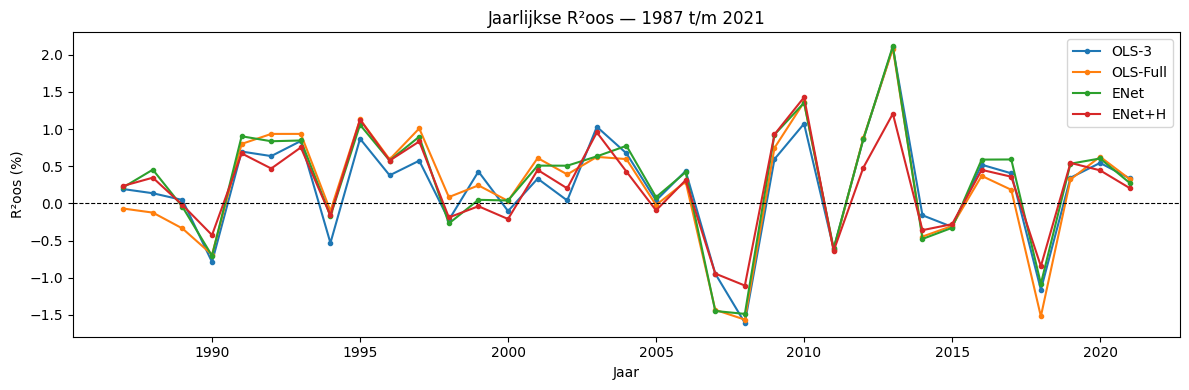

In [26]:
# Tabel 2: Jaarlijkse R²oos
years = sorted(set().union(*(m['annual'].keys() for m in rec_metrics.values())))
t2_rows = []
for yr in years:
    row = {'Year': yr}
    for model_key in available_model_keys:
        m = rec_metrics[model_key]
        label = MODEL_DISPLAY_NAMES[model_key]
        if yr in m['annual'] and m['annual'][yr][1] > 0:
            row[label] = (1 - m['annual'][yr][0] / m['annual'][yr][1]) * 100
        else:
            row[label] = np.nan
    t2_rows.append(row)
tabel2 = pd.DataFrame(t2_rows)
print('=== TABEL 2: Jaarlijkse R²oos (%) ===')
print(tabel2.to_string(index=False))
tabel2.to_csv(OUTPUT_DIR / 'tabel2_annual_r2oos.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 4))
for model_key in available_model_keys:
    label = MODEL_DISPLAY_NAMES[model_key]
    ax.plot(tabel2['Year'], tabel2[label], label=label, marker='o', markersize=3)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Jaar')
ax.set_ylabel('R²oos (%)')
ax.set_title('Jaarlijkse R²oos — 1987 t/m 2021')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tabel2_annual_r2oos.png', dpi=150)
plt.show()


In [27]:
# Tabel 3: DM-test MSE-reeksen
dm_df = pd.DataFrame({
    f'mse_{model_key}': rec_metrics[model_key]['mse_series']
    for model_key in available_model_keys
}).sort_index()

# Newey-West-achtige standaardfout met lag=12
def dm_test(d):
    d = np.asarray(d)
    n = len(d)
    mean = d.mean()
    gamma0 = ((d - mean) ** 2).mean()
    lag = 12
    s = gamma0
    for k in range(1, lag + 1):
        w = 1 - k / (lag + 1)
        g = ((d[k:] - mean) * (d[:-k] - mean)).mean()
        s += 2 * w * g
    se = np.sqrt(s / n)
    return mean / se if se > 0 else np.nan

dm_results = []
if len(available_model_keys) < 2:
    print('=== TABEL 3: DM-test statistieken ===')
    print('DM-test skipped: at least two recursive models are required.')
    dm_tab = pd.DataFrame(columns=['model_A', 'model_B', 'DM_stat'])
else:
    pairs = []
    for idx, model_a in enumerate(available_model_keys):
        for model_b in available_model_keys[idx + 1:]:
            pairs.append((model_a, model_b))

    for model_a, model_b in pairs:
        d = dm_df[f'mse_{model_a}'] - dm_df[f'mse_{model_b}']
        dm_results.append({
            'model_A': MODEL_DISPLAY_NAMES[model_a],
            'model_B': MODEL_DISPLAY_NAMES[model_b],
            'DM_stat': dm_test(d.dropna().values),
        })

    dm_tab = pd.DataFrame(dm_results)
    print('=== TABEL 3: DM-test statistieken (positief = A slechter dan B) ===')
    print(dm_tab.to_string(index=False))

dm_tab.to_csv(OUTPUT_DIR / 'tabel3_dm_tests.csv', index=False)
dm_df.to_csv(OUTPUT_DIR / 'tabel3_dm_mse_series.csv')


=== TABEL 3: DM-test statistieken (positief = A slechter dan B) ===
 model_A  model_B   DM_stat
   OLS-3 OLS-Full  1.089600
   OLS-3     ENet  1.977796
   OLS-3   ENet+H  0.471392
OLS-Full     ENet  1.098383
OLS-Full   ENet+H -0.490455
    ENet   ENet+H -1.659489


In [28]:
# Tabel 7: Decile portfolios
decile_tables = {}
decile_sharpes = {}
for model_key in available_model_keys:
    dec_df, ls_sharpe = decile_table(rec_metrics[model_key], MODEL_DISPLAY_NAMES[model_key])
    decile_tables[model_key] = dec_df
    decile_sharpes[model_key] = ls_sharpe
    dec_df.to_csv(OUTPUT_DIR / f'tabel7_decile_{MODEL_FILE_TAGS[model_key]}.csv', index=False)



OLS-3 — Decile portfolios:
 Decile  Avg Return (ann.)  Std (ann.)   Sharpe
      1           0.050269    0.268556 0.187183
      2           0.077412    0.237893 0.325406
      3           0.093888    0.219757 0.427235
      4           0.086774    0.210976 0.411297
      5           0.096805    0.213071 0.454332
      6           0.115861    0.206716 0.560484
      7           0.121190    0.201242 0.602213
      8           0.125624    0.188572 0.666188
      9           0.153316    0.182069 0.842076
     10           0.194105    0.199967 0.970686
L-S Avg: 0.1438  Sharpe: 0.7636

OLS-Full — Decile portfolios:
 Decile  Avg Return (ann.)  Std (ann.)    Sharpe
      1          -0.044915    0.253485 -0.177190
      2           0.039820    0.230092  0.173060
      3           0.074983    0.212090  0.353543
      4           0.086708    0.200453  0.432559
      5           0.106540    0.199288  0.534603
      6           0.116184    0.192989  0.602021
      7           0.144893    0.199054

In [29]:
# Tabel 8: Risico-gecorrigeerde prestaties
t8_rows = []
for model_key in available_model_keys:
    t8_rows.append(risk_metrics(rec_metrics[model_key]['ls_series'], MODEL_DISPLAY_NAMES[model_key]))
tabel8 = pd.DataFrame(t8_rows)
print('\n=== TABEL 8: Risico-gecorrigeerde prestaties ===')
print(tabel8.to_string(index=False))
tabel8.to_csv(OUTPUT_DIR / 'tabel8_risk_adjusted.csv', index=False)


OLS-3: Sharpe=0.7626  MaxDD=-49.10%  Worst=-30.33%
OLS-Full: Sharpe=1.6121  MaxDD=-45.43%  Worst=-30.10%
ENet: Sharpe=1.3759  MaxDD=-59.93%  Worst=-26.91%
ENet+H: Sharpe=1.2378  MaxDD=-63.16%  Worst=-30.37%

=== TABEL 8: Risico-gecorrigeerde prestaties ===
   Model   Sharpe     MaxDD  Worst Month
   OLS-3 0.762642 -0.490999    -0.303275
OLS-Full 1.612059 -0.454342    -0.300972
    ENet 1.375942 -0.599279    -0.269066
  ENet+H 1.237808 -0.631618    -0.303657


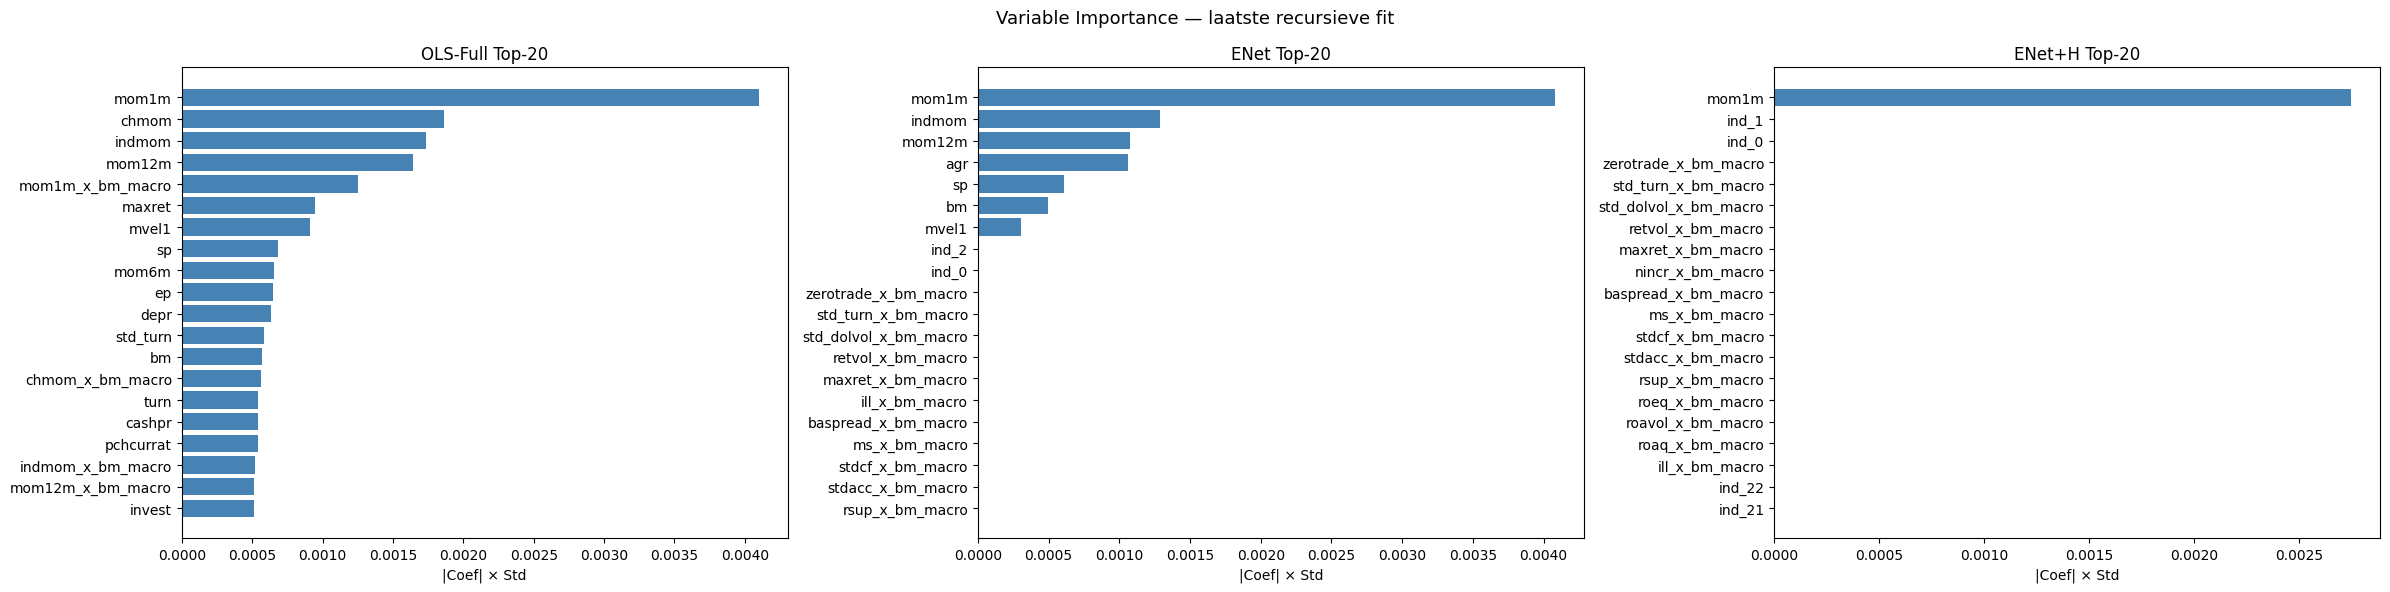

In [31]:
# Figuur 4: Variable importance — gebruik de LAATSTE refit (most-recent coefficients)
last_year = 2021
refit_coefs = {}
importance_tables = {}
available_full_feature_models = [
    model_key for model_key in available_model_keys
    if model_key in {'ols_full', 'enet', 'enet_h'}
]

if not available_full_feature_models:
    print('Figuur 4 skipped: no full-feature recursive linear models were run.')
else:
    tr_last = load_block(None, year_end(last_year - 13), cols_full).dropna(subset=[TARGET])
    tr_last = impute_cs_median(tr_last, ALL_FEATURES)
    X_last = feature_matrix(tr_last, ALL_FEATURES)
    y_last = target_vector(tr_last)
    feat_std = tr_last[ALL_FEATURES].std().to_numpy(dtype=np.float32, copy=False)

    hp_last = hp_df[hp_df['year'] == last_year].iloc[0] if not hp_df.empty else None

    for model_key in available_full_feature_models:
        if model_key == 'ols_full':
            model = LinearRegression().fit(X_last, y_last)
            coef = model.coef_
        elif model_key == 'enet':
            model = ElasticNet(
                alpha=float(hp_last['alpha_enet']),
                l1_ratio=float(hp_last['l1_enet']),
                max_iter=5000,
                fit_intercept=True,
            ).fit(X_last, y_last)
            coef = model.coef_
        else:
            xi_last = float(np.percentile(np.abs(y_last), 99.9))
            model = SGDRegressor(
                loss='huber',
                epsilon=xi_last,
                penalty='elasticnet',
                alpha=float(hp_last['alpha_enet_h']),
                l1_ratio=float(hp_last['l1_enet_h']),
                max_iter=1000,
                random_state=42,
            ).fit(X_last, y_last)
            coef = model.coef_

        refit_coefs[model_key] = np.asarray(coef, dtype=np.float64)
        importance_tables[model_key] = pd.DataFrame({
            'feature': ALL_FEATURES,
            'importance': np.abs(refit_coefs[model_key]) * feat_std,
        }).sort_values('importance', ascending=False)

    del tr_last, X_last, y_last

    fig, axes = plt.subplots(1, len(available_full_feature_models), figsize=(8 * len(available_full_feature_models), 6))
    if len(available_full_feature_models) == 1:
        axes = [axes]

    for ax, model_key in zip(axes, available_full_feature_models):
        imp = importance_tables[model_key].head(20)
        ax.barh(imp['feature'].values[::-1], imp['importance'].values[::-1], color='steelblue')
        ax.set_title(f'{MODEL_DISPLAY_NAMES[model_key]} Top-20')
        ax.set_xlabel('|Coef| × Std')

    plt.suptitle('Variable Importance — laatste recursieve fit', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'figuur4_variable_importance.png', dpi=150)
    plt.show()

    for model_key, imp_df in importance_tables.items():
        imp_df.to_csv(OUTPUT_DIR / f'figuur4_importance_{MODEL_FILE_TAGS[model_key]}.csv', index=False)


In [32]:
# Eindoverzicht
print('=== EINDOVERZICHT — Recursieve resultaten ===')
print(f'Testperiode: {TEST_START} t/m {TEST_END}')
print()
for model_key in available_model_keys:
    doel = GKX_TARGET_R2[model_key]
    print(f'{MODEL_DISPLAY_NAMES[model_key]:10s}  R²oos = {rec_metrics[model_key]["r2"] * 100:+.4f}%   (doel GKX: {doel:+.2f}%)')
print()
print(f'Alle bestanden opgeslagen in: {OUTPUT_DIR.resolve()}')


=== EINDOVERZICHT — Recursieve resultaten ===
Testperiode: 1987-01 t/m 2021-12

OLS-3       R²oos = +0.2331%   (doel GKX: +0.16%)
OLS-Full    R²oos = +0.2992%   (doel GKX: -3.46%)
ENet        R²oos = +0.3174%   (doel GKX: +0.11%)
ENet+H      R²oos = +0.2583%   (doel GKX: +0.11%)

Alle bestanden opgeslagen in: /content/ols_output


In [33]:
# ====================================================
# Save lean recursive OOS predictions for selected models
# ====================================================
from pathlib import Path
import pandas as pd

prediction_output_dir = Path("/content/drive/MyDrive/Replication Paper/Data/Results/fml_ols_enet_results")
prediction_output_dir.mkdir(parents=True, exist_ok=True)

source_notebook = "FML_OLS_ENet_fixed.ipynb"
prediction_source = "fml_ols_enet_fixed"
prediction_scope = "stock_level_oos_model_predictions_only"

model_prediction_frames = {
    MODEL_EXPORT_NAMES[model_key]: rec_dfs[model_key]
    for model_key in available_model_keys
}

def prepare_prediction_export(df, model_name):
    out_df = df.copy()
    out_df["date"] = out_df["date"].astype(str)
    out_df["test_year"] = out_df["date"].str[:4].astype(int)
    out_df = out_df.rename(columns={"pred": "prediction"})
    out_df["predicted"] = out_df["prediction"]
    out_df.insert(0, "source_notebook", source_notebook)
    out_df.insert(1, "prediction_source", prediction_source)
    out_df.insert(2, "prediction_scope", prediction_scope)
    out_df.insert(3, "model", model_name)

    if model_name == "enet_recursive":
        hp_cols = hp_df[["year", "alpha_enet", "l1_enet"]].rename(
            columns={"year": "test_year", "alpha_enet": "alpha", "l1_enet": "l1_ratio"}
        )
        spar_cols = spar_df[["year", "n_nonzero_enet"]].rename(
            columns={"year": "test_year", "n_nonzero_enet": "n_nonzero_features"}
        )
        out_df = out_df.merge(hp_cols, on="test_year", how="left")
        out_df = out_df.merge(spar_cols, on="test_year", how="left")
    elif model_name == "enet_h_recursive":
        hp_cols = hp_df[["year", "alpha_enet_h", "l1_enet_h"]].rename(
            columns={"year": "test_year", "alpha_enet_h": "alpha", "l1_enet_h": "l1_ratio"}
        )
        spar_cols = spar_df[["year", "n_nonzero_enet_h"]].rename(
            columns={"year": "test_year", "n_nonzero_enet_h": "n_nonzero_features"}
        )
        out_df = out_df.merge(hp_cols, on="test_year", how="left")
        out_df = out_df.merge(spar_cols, on="test_year", how="left")

    export_cols = [
        "source_notebook", "prediction_source", "prediction_scope", "model",
        "test_year", "date", "permno", "prediction", "predicted",
        "alpha", "l1_ratio", "n_nonzero_features",
    ]
    export_cols = [c for c in export_cols if c in out_df.columns]
    return out_df[export_cols]

saved_prediction_frames = []
saved_prediction_paths = []

for model_name, pred_df in model_prediction_frames.items():
    out_df = prepare_prediction_export(pred_df, model_name)
    out_path = prediction_output_dir / f"FML_OLS_ENet_fixed_{model_name}_oos_predictions.parquet"
    out_df.to_parquet(out_path, index=False)
    saved_prediction_frames.append(out_df)
    saved_prediction_paths.append({
        "source_notebook": source_notebook,
        "prediction_source": prediction_source,
        "model": model_name,
        "rows": len(out_df),
        "columns": ",".join(out_df.columns),
        "path": str(out_path),
    })
    print(f"Saved {model_name} lean predictions ({len(out_df):,} rows) to {out_path}")

all_oos_predictions = pd.concat(saved_prediction_frames, ignore_index=True)
all_oos_path = prediction_output_dir / "FML_OLS_ENet_fixed_all_recursive_oos_predictions.parquet"
all_oos_predictions.to_parquet(all_oos_path, index=False)

manifest_df = pd.DataFrame(saved_prediction_paths)
manifest_df.loc[len(manifest_df)] = {
    "source_notebook": source_notebook,
    "prediction_source": prediction_source,
    "model": "all_recursive_models",
    "rows": len(all_oos_predictions),
    "columns": ",".join(all_oos_predictions.columns),
    "path": str(all_oos_path),
}
manifest_path = prediction_output_dir / "FML_OLS_ENet_fixed_prediction_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print(f"Saved combined lean recursive predictions ({len(all_oos_predictions):,} rows) to {all_oos_path}")
print(f"Saved prediction manifest to {manifest_path}")
print("\nDone! Lean recursive OOS predictions saved for the selected models.")


Saved ols3_recursive lean predictions (2,136,916 rows) to /content/drive/MyDrive/Replication Paper/Data/Results/fml_ols_enet_results/FML_OLS_ENet_fixed_ols3_recursive_oos_predictions.parquet
Saved ols_full_recursive lean predictions (2,136,916 rows) to /content/drive/MyDrive/Replication Paper/Data/Results/fml_ols_enet_results/FML_OLS_ENet_fixed_ols_full_recursive_oos_predictions.parquet
Saved enet_recursive lean predictions (2,136,916 rows) to /content/drive/MyDrive/Replication Paper/Data/Results/fml_ols_enet_results/FML_OLS_ENet_fixed_enet_recursive_oos_predictions.parquet
Saved enet_h_recursive lean predictions (2,136,916 rows) to /content/drive/MyDrive/Replication Paper/Data/Results/fml_ols_enet_results/FML_OLS_ENet_fixed_enet_h_recursive_oos_predictions.parquet
Saved combined lean recursive predictions (8,547,664 rows) to /content/drive/MyDrive/Replication Paper/Data/Results/fml_ols_enet_results/FML_OLS_ENet_fixed_all_recursive_oos_predictions.parquet
Saved prediction manifest to /